Current dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing
Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing\FDTD_Results
Min: (-0.80, -200.50) µm
Max: (100.50, 0.50) µm
Center: (49.85, -100.00) µm
Span: 101.30 x 201.00 µm


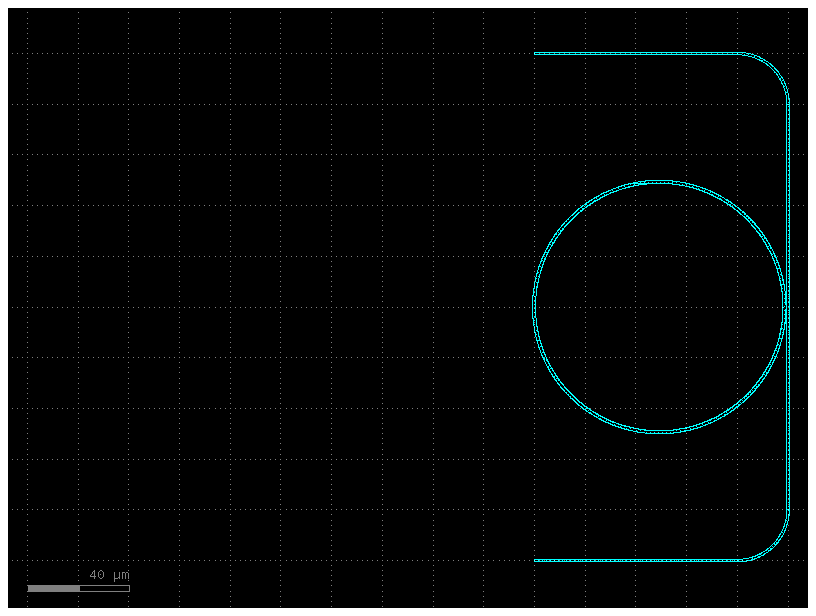

In [1]:

import sys, os
import numpy as np
import matplotlib.pyplot as plt
from   pathlib import Path
import time

import gdsfactory as gf
# gf.gpdk.PDK.activate()

total_start = time.time()

# ----------------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------------
WorkDir   = Path().resolve()       # D:\...\scripts\directional_coupler
print("Current dir :", WorkDir)
REPO_ROOT = WorkDir.parents[1]     # D:\Ligentic_NU_1_TapeOut_April2026
os.chdir(WorkDir)

DataDir = WorkDir / "FDTD_Results"
DataDir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WorkDir)
print("Data save   :", DataDir)

#------------------------------------------------------------
# GEOMETRY SETUP (LOAD EXISTING)
#------------------------------------------------------------
gf.clear_cache()

gds_path = str(WorkDir / "APF_M_R50_M358_362_DW020_G300.gds")
device   = gf.import_gds(gds_path)

# Extract the bounding box
bbox = device.bbox()

xmin, ymin = bbox.left, bbox.bottom
xmax, ymax = bbox.right, bbox.top
center_x   = (xmin + xmax) / 2.0
center_y   = (ymin + ymax) / 2.0
span_x     = xmax - xmin
span_y     = ymax - ymin

# Verification
print(f"Min: ({xmin:.2f}, {ymin:.2f}) µm")
print(f"Max: ({xmax:.2f}, {ymax:.2f}) µm")
print(f"Center: ({center_x:.2f}, {center_y:.2f}) µm")
print(f"Span: {span_x:.2f} x {span_y:.2f} µm")
# Verify geometry
device.plot()

In [2]:
# ----------------------------------------------------------------------------------
# Lumerical API and Session
# ----------------------------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  # QP5

import lumapi as lm

f = lm.MODE()

LumFileName = "Test_APF_M.lms"
LumFilePath = str(WorkDir / LumFileName)
f.save(LumFilePath)

f.switchtolayout()
f.selectall()
f.delete()

#------------------------------------------------------------
# GDS load to Lum
#------------------------------------------------------------

Material           = "Si3N4 (Silicon Nitride) - Luke"
UseIndex           = True
Index              = 1.97        # optional, used if material = '<Object defined dielectric>'
BackgroundMaterial = "SiO2 (Glass) - Palik"
Height             = 800E-9

device.write_gds(gds_path)
f.gdsimport(gds_path, device.name, "2:0", Material, 0, Height)

if UseIndex:
    f.set("material", "<Object defined dielectric>")
    f.set("index", Index)

C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [3]:
#------------------------------------------------------------
# Parameters (from gds)
#------------------------------------------------------------

Gap          = 300E-9
WgWidth      = 1.2E-6
WgWidthIO    = 1.0E-6
BendRadius   = 50E-6

M            = 360
DW           = 0.05E-6

LambdaStart        = 1530E-9
LambdaStop         = 1570E-9

SimulationTime     = 200E-12
FrequencyPoints    = 40000
decay_rate         = 1E-3

FArrayGap      = 200E-6
InLengthY      = FArrayGap/2
InLengthX      = 100E-6

Margin  = 10E-6

xmin    =  InLengthX - 2*BendRadius - 1*Margin
ymin    = -InLengthY - BendRadius - Margin

SimXSpan = 2*BendRadius + 2*Margin
SimYSpan = 2*BendRadius + 2*Margin

x0     = -SimXSpan/2 + 2*BendRadius + Margin
y0     = -SimYSpan/2 + Margin

SourcePosX =  InLengthX 
SourcePosY = -InLengthY + 1*BendRadius + 0.5*Margin

TH_PosX    =  InLengthX 
TH_PosY    =  -InLengthY - 1*BendRadius - 0.5*Margin

tag      = f"Test_APF_M_Gap_{Gap*1e9:.0f}nm_R{BendRadius*1e6:.0f}um_M{M}_DW{DW*1e6:.0f}nm"
fname    = DataDir / f"{tag}.txt"
print(f"Data file: {fname}")


#------------------------------------------------------------
# varFDTD
#------------------------------------------------------------
f.addvarfdtd()
f.set("simulation time", SimulationTime)
f.set("x0", x0)
f.set("y0", y0)
f.set("x min", xmin)
f.set("y min", ymin)
f.set("x max", xmin+SimXSpan)
f.set("y max", ymin+SimYSpan)
f.set("z", Height / 2)
f.set("z span", 8 * Height)
f.set("background material", BackgroundMaterial)
f.set("set simulation bandwidth", 1)
f.set("bandwidth", "broadband")
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min", decay_rate)

f.set("x min bc", "PML")
f.set("x max bc", "PML")
f.set("y min bc", "PML")
f.set("y max bc", "PML")
f.set("z min bc", "PML")
f.set("z max bc", "PML")


#------------------------------------------------------------
# SOURCE — at o3 (input), inject +x
#------------------------------------------------------------
# f.addmodesource()
# f.set("name", "ModeSource")
# f.set("x", SourcePosX)
# f.set("y", SourcePosY)
# f.set("y span", 3 * WgWidth)
# f.set("injection axis", "y-axis")
# f.set("direction", "Backward")
# f.set("amplitude", 1.0)
# f.set("phase", 0)
# f.set("mode selection", "fundamental mode")
# f.set("set wavelength", 1)
# f.set("wavelength start", LambdaStart)
# f.set("wavelength stop", LambdaStop)

f.addplane()
f.set("name", "PlaneWaveSource")
f.set("injection axis", "y-axis")
f.set("x", SourcePosX)
f.set("y", SourcePosY)
f.set("x span", WgWidth)
f.set("use relative coordinates", 1)
f.set("direction", "Backward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)


#------------------------------------------------------------
# MONITOR: Through
#------------------------------------------------------------
f.adddftmonitor()
f.set("name", "TH")
f.set("monitor type", "Linear X")
f.set("x", TH_PosX)
f.set("y", TH_PosY)
f.set("x span", 3 * WgWidth)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)




Data file: D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing\FDTD_Results\Test_APF_M_Gap_300nm_R50um_M360_DW0nm.txt


In [4]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------

f.run()


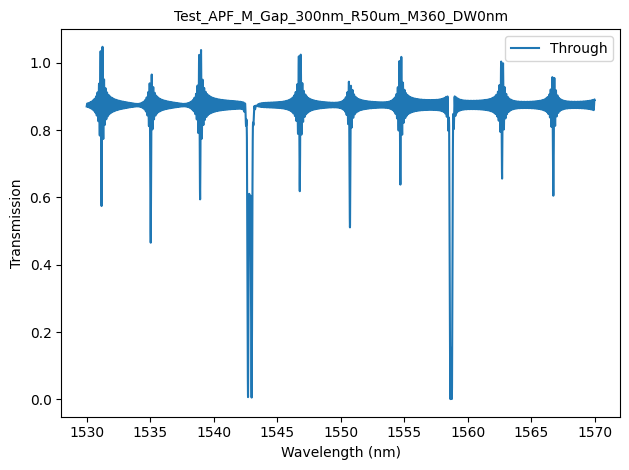

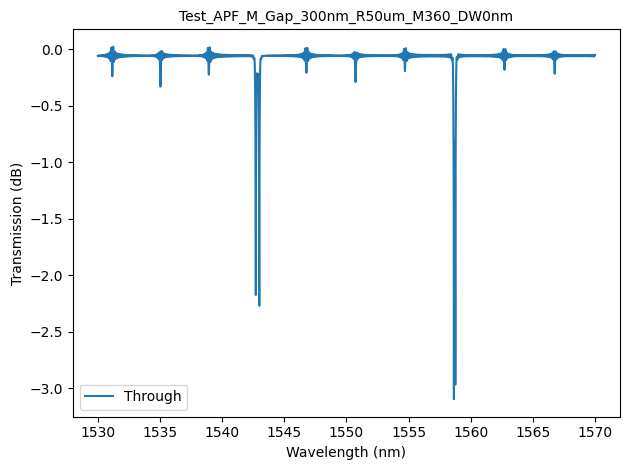

In [5]:

#------------------------------------------------------------
# Extract Results
#------------------------------------------------------------
try:
    T_TH = f.getresult("TH", "T")
    

    Tx_Through = np.abs(T_TH["T"].flatten())
    
    Wavelength = T_TH["lambda"].flatten()
except Exception as e:
    print(f"  ⚠ SKIPPED | {e}")

#------------------------------------------------------------
# Plot
#------------------------------------------------------------
fig1 = plt.figure()
plt.plot(Wavelength*1e9, Tx_Through, label="Through")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission")
plt.title(f"{tag}", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(DataDir / f"{fname}_lin.png", dpi=300, bbox_inches='tight')
# mplcursors.cursor(hover=True)
# disconnect_zoom = zoom_factory(plt.gca())
plt.show()

fig2 = plt.figure()
plt.plot(Wavelength*1e9, np.log10(Tx_Through), label="Through")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (dB)")
plt.title(f"{tag}", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(DataDir / f"{fname}_log.png", dpi=300, bbox_inches='tight')
# mplcursors.cursor(hover=True)
# disconnect_zoom = zoom_factory(plt.gca())
plt.show()



In [6]:

#------------------------------------------------------------
# Save Data
#------------------------------------------------------------

meta = {
    "Width_nm"          : WgWidth  * 1e9,
    "Height_nm"         : Height * 1e9,
    "Radius_um"         : BendRadius * 1e6,
    "Gap_nm"            : Gap    * 1e9,
    "Material"          : Material,
    "Index"             : Index,
    "UseIndex"          : UseIndex,
    "Timestamp"         : time.strftime("%Y%m%d_%H%M%S"),
}

with open(fname, "w") as file:
    for k, v in meta.items():
        file.write(f"# {k}: {v}\n")
    file.write("# Wavelength_nm\tTx_Through\n")

data = np.column_stack([Wavelength*1e9, Tx_Through])
with open(fname, "ab") as file:
    np.savetxt(file, data, delimiter="\t")

print(f"Saved: {fname}")

Saved: D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing\FDTD_Results\Test_APF_M_Gap_300nm_R50um_M360_DW0nm.txt
